# <div style="background: linear-gradient(90deg, #0f172a, #1d4ed8); padding: 16px 20px; border-radius: 12px; color: white;">
# CIC IIoT Dataset 2025: Benign Data Exploration
# </div>

<div style="margin-top: 12px; padding: 14px 18px; border-left: 6px solid #2563eb; background: #eff6ff; border-radius: 8px;">
<b>Research question:</b> Does using a knowledge graph with a graph neural network (GNN) detect attacks on IoT better than using normal models that do not use graphs?<br>
<b>Hypothesis:</b> A knowledge graph + GNN can achieve better performance for intrusion detection in IoT environments.
</div>

## Purpose of this notebook

This notebook analyzes the file `benign_samples_1sec.csv`, which contains only benign traffic. That matters because:

- it is useful to understand what normal IoT behavior looks like,
- it can help build a baseline for anomaly detection,
- it can support the future construction of a knowledge graph,
- but it cannot by itself train a supervised attack-vs-benign classifier.

## Main goals

1. Understand the structure and quality of the dataset.
2. Identify relationships and trends in normal IoT traffic.
3. Determine whether this dataset is useful for the project.
4. Document insights in a way that can later support the research paper.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

DATASET_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv")
DATASET_PATH


PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv')

## <div style="color:#1d4ed8;">1. Load the data</div>

We first load the dataset and convert the timestamps to datetime format. The data appears to be aggregated in 1-second windows, which is useful because each row summarizes network and logging behavior over a short period of time.

In [2]:
df = pd.read_csv(DATASET_PATH)

df['timestamp_start'] = pd.to_datetime(df['timestamp_start'], utc=True)
df['timestamp_end'] = pd.to_datetime(df['timestamp_end'], utc=True)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 136,800
Columns: 94


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,network_ip-flags_std_deviation,network_ip-length_avg,network_ip-length_max,network_ip-length_min,network_ip-length_std_deviation,network_ips_all,network_ips_all_count,network_ips_dst,network_ips_dst_count,network_ips_src,network_ips_src_count,network_macs_all,network_macs_all_count,network_macs_dst,network_macs_dst_count,network_macs_src,network_macs_src_count,network_mss_avg,network_mss_max,network_mss_min,network_mss_std_deviation,network_packet-size_avg,network_packet-size_max,network_packet-size_min,network_packet-size_std_deviation,network_packets_all_count,network_packets_dst_count,network_packets_src_count,network_payload-length_avg,network_payload-length_max,network_payload-length_min,network_payload-length_std_deviation,network_ports_all,network_ports_all_count,network_ports_dst,network_ports_dst_count,network_ports_src,network_ports_src_count,network_protocols_all,network_protocols_all_count,network_protocols_dst,network_protocols_dst_count,network_protocols_src,network_protocols_src_count,network_tcp-flags-ack_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-rst_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_avg,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_avg,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:40.400000Z_2025-09-09T14:09:4...,2025-09-09 14:09:40.400000+00:00,2025-09-09 14:09:41.400000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,161.500000,2.0,2.0,2.0,0.0,610.200000,2265.0,52.0,838.129680,"['192.168.1.193', '192.168.230.7', '192.168.1....",4,"['192.168.1.193', '192.168.230.7', '192.168.1....",3,"['192.168.1.193', '192.168.230.7', '192.168.1.1']",3,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46', 'ff...",3,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c', 'ff...",2,"['28:87:ba:bd:c6:6c', 'dc:a6:32:dc:28:46']",2,0.0,0.0,0.0,0.0,624.200000,2279.0,66.0,838.129680,5,2,3,564.600000,2213.0,0.0,836.582716,"['57688', '9200', '20002', '44935']",4,"['57688', '9200', '20002']",3,"['57688', '9200', '44935']",3,"['tcp', 'data', 'json']",3,"['tcp', 'json']",2,"['tcp', 'data', 'json']",3,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.004623,0.016136,0.0,0.006059,62.800000,64.0,61.0,1.469694,1870.500000,3081.0,660.0,1210.500000
1,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:41.400000Z_2025-09-09T14:09:4...,2025-09-09 14:09:41.400000+00:00,2025-09-09 14:09:42.400000+00:00,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,20.0,20.0,20.0,0.0,1.666667,2.0,2.0,2.0,0.0,577.500000,1920.0,52.0,780.957585,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['192.168.1.193', '192.168.230.7']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,"['dc:a6:32:dc:28:46', '28:87:ba:bd:c6:6c']",2,0.0,0.0,0.0,0.0,591.500000,1934.0,66.0,780.957585,4,2,2,525.500000,1868.0,0.0,780.957585,"['57688', '9200']",2,"['57688', '9200']",2,"['57688', '9200']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,"['tcp', 'json']",2,4,0,2,0,0,0,20.000000,24.0,16.0,4.000000,0.010692,0.039098,0.0,0.016469,62.500000,64.0,61.0,1.500000,1870

## <div style="color:#1d4ed8;">2. Quick profile of the dataset</div>

The following summary helps us answer basic research questions:

- Is the dataset labeled?
- Does it contain both benign and attack observations?
- How many IoT devices appear?
- What time period does it cover?
- Are the observations balanced across devices?


In [3]:
profile = {
    'rows': df.shape[0],
    'columns': df.shape[1],
    'unique_devices': df['device_name'].nunique(),
    'unique_device_macs': df['device_mac'].nunique(),
    'label_full_unique': df['label_full'].nunique(),
    'label1_unique': df['label1'].nunique(),
    'time_start': df['timestamp_start'].min(),
    'time_end': df['timestamp_end'].max(),
    'duration_minutes': (df['timestamp_end'].max() - df['timestamp_start'].min()).total_seconds() / 60,
}

profile_df = pd.DataFrame(profile.items(), columns=['Metric', 'Value'])
profile_df


,Metric,Value
0,rows,136800
1,columns,94
2,unique_devices,38
3,unique_device_macs,38
4,label_full_unique,1
5,label1_unique,1
6,time_start,2025-09-09 14:09:40.400000+00:00
7,time_end,2025-09-09 15:09:40.400000+00:00
8,duration_minutes,60.0


In [4]:
for col in ['label_full', 'label1', 'label2', 'label3', 'label4']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False).to_string())



Value counts for label_full:
label_full
benign_whole-network3    136800

Value counts for label1:
label1
benign    136800

Value counts for label2:
label2
benign    136800

Value counts for label3:
label3
benign    136800

Value counts for label4:
label4
benign    136800


In [5]:
device_observation_summary = (
    df.groupby('device_name')
      .agg(
          windows=('device_name', 'size'),
          mean_packets=('network_packets_all_count', 'mean'),
          mean_ips=('network_ips_all_count', 'mean'),
          mean_ports=('network_ports_all_count', 'mean'),
          mean_payload=('network_payload-length_avg', 'mean')
      )
      .sort_values('mean_packets', ascending=False)
)

device_observation_summary.head(15)


,windows,mean_packets,mean_ips,mean_ports,mean_payload
device_name,,,,,
mqtt-broker,3600,39.096389,11.865556,12.670278,83.240313
router,3600,22.096944,8.788889,4.647222,458.564152
weather-sensor,3600,5.565278,1.954167,1.852778,39.998865
gas-sensor,3600,4.260556,2.091389,2.002778,10.478113
sound-sensor,3600,4.260556,2.092500,2.002222,10.967771
light-sensor,3600,4.145556,2.036389,1.944444,19.040979
vibration-sensor,3600,3.625000,0.817500,0.626667,3.123242
accelerometer-sensor,3600,3.293333,2.092778,2.001667,13.515606
blurams-camera,3600,2.432222,0.734444,0.765556,28.400991


### Interpretation

<div style="padding: 12px 16px; background: #f8fafc; border-radius: 8px; border: 1px solid #cbd5e1;">
This dataset contains <b>only benign traffic</b>. All label columns point to the same benign class. That means this file is excellent for understanding <b>normal behavior</b>, but it is <b>not enough</b> to answer the full research question by itself because there are no attack samples to compare against.
</div>

A positive point is that the dataset includes many devices and one hour of second-by-second observations, which is useful for:

- learning normal communication patterns,
- identifying which devices are more active,
- defining graph entities such as devices, IPs, MACs, protocols, and ports.


## <div style="color:#1d4ed8;">3. Column groups and what they mean</div>

This dataset mixes metadata, logging features, and network traffic features. These groups are important for both classical models and graph-based models.

In [6]:
column_groups = {
    'Identity and labels': [c for c in df.columns if c in ['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4']],
    'Time fields': [c for c in df.columns if c.startswith('timestamp')],
    'Log features': [c for c in df.columns if c.startswith('log_')],
    'Network count features': [c for c in df.columns if c.startswith('network_') and c.endswith('_count')],
    'Network averages / min / max / std': [c for c in df.columns if c.startswith('network_') and any(tag in c for tag in ['_avg', '_min', '_max', '_std_deviation'])],
    'List-like network context': [c for c in df.columns if c.startswith('network_') and df[c].dtype == 'object' and c not in ['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4', 'timestamp', 'timestamp_start', 'timestamp_end']]
}

for group, cols in column_groups.items():
    print(f"\n{group} ({len(cols)} columns)")
    print(cols[:15], '...' if len(cols) > 15 else '')



Identity and labels (7 columns)
['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4'] 

Time fields (3 columns)
['timestamp', 'timestamp_start', 'timestamp_end'] 

Log features (8 columns)
['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types', 'log_data-types_count', 'log_interval-messages', 'log_messages_count'] 

Network count features (21 columns)
['network_ips_all_count', 'network_ips_dst_count', 'network_ips_src_count', 'network_macs_all_count', 'network_macs_dst_count', 'network_macs_src_count', 'network_packets_all_count', 'network_packets_dst_count', 'network_packets_src_count', 'network_ports_all_count', 'network_ports_dst_count', 'network_ports_src_count', 'network_protocols_all_count', 'network_protocols_dst_count', 'network_protocols_src_count'] ...

Network averages / min / max / std (40 columns)
['network_header-length_avg', 'network_header-length_max', 'network_header-length_

### Why this matters

- **For classical machine learning:** numeric columns such as packet counts, packet sizes, TTL, payload length, and protocol counts can become model features.
- **For a knowledge graph:** list-like columns such as IPs, MACs, ports, and protocols are especially valuable because they naturally define relationships between entities.

Example graph idea:

- a device node connects to an IP node,
- a device node uses a protocol node,
- a device node communicates through a port node,
- time windows can become event nodes or temporal edges.


## <div style="color:#1d4ed8;">4. Data quality checks</div>

Before modeling, we need to know whether the dataset is clean enough to trust.

In [7]:
null_summary = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

numeric_df = df.select_dtypes(include='number')
constant_numeric = [c for c in numeric_df.columns if numeric_df[c].nunique(dropna=False) == 1]
zero_rate = (numeric_df == 0).mean().sort_values(ascending=False)

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Columns with missing values: {(null_summary > 0).sum()}")
print("\nTop missing-value counts:")
print(null_summary.head(15).to_string())
print("\nConstant numeric columns:")
print(constant_numeric)
print("\nHighest zero-rate numeric columns:")
print(zero_rate.head(15).to_string())


Duplicate rows: 0
Columns with missing values: 0

Top missing-value counts:
device_name                             0
network_payload-length_std_deviation    0
network_protocols_dst                   0
network_protocols_all_count             0
network_protocols_all                   0
network_ports_src_count                 0
network_ports_src                       0
network_ports_dst_count                 0
network_ports_dst                       0
network_ports_all_count                 0
network_ports_all                       0
network_payload-length_min              0
network_protocols_src                   0
network_payload-length_max              0
network_payload-length_avg              0

Constant numeric columns:
['network_fragmentation-score', 'network_fragmented-packets', 'network_tcp-flags-urg_count']

Highest zero-rate numeric columns:
network_tcp-flags-urg_count            1.000000
network_fragmentation-score            1.000000
network_fragmented-packets             1.0

## <div style="color:#1d4ed8;">5. Descriptive statistics for key traffic features</div>

These variables summarize traffic intensity, direction, diversity, timing, and packet behavior. I selected them because they are easy to explain, they are useful for classical machine learning, and they also help us think about what a future graph representation should preserve.

### What each column means

- **`network_packets_all_count`**: total number of packets seen in the 1-second window. This is one of the clearest indicators of activity level. Very high values may later suggest flooding behavior.
- **`network_packets_src_count`**: number of packets sent from the source side during the window. This helps us understand outgoing activity.
- **`network_packets_dst_count`**: number of packets received on the destination side during the window. Comparing source and destination counts can reveal whether communication is balanced or one-sided.
- **`network_ips_all_count`**: number of unique IP addresses involved in that window. Higher values usually mean the device is communicating with more distinct endpoints.
- **`network_ports_all_count`**: number of unique ports observed in the window. This is useful because normal traffic often uses a limited set of ports, while attacks may touch many more.
- **`network_protocols_all_count`**: number of unique protocols present in the window. A stable device often uses only a few protocols, so abrupt changes may later be suspicious.
- **`network_packet-size_avg`**: average packet size in the window. This helps us see whether traffic is made of small control packets or larger data packets.
- **`network_payload-length_avg`**: average payload length. This is especially helpful for distinguishing traffic that carries real content from traffic that mostly consists of headers or control behavior.
- **`network_ttl_avg`**: average Time To Live (TTL). TTL can indirectly reflect path characteristics, routing behavior, or device/network configuration patterns.
- **`network_time-delta_avg`**: average time gap between packets. Small values often mean packets are arriving rapidly; larger values suggest more spaced-out communication.

### Why I focused on these variables

I chose these columns because together they answer several practical questions:

- How much traffic is happening?
- Is the device mostly sending, receiving, or both?
- Is it talking to many IPs, ports, or protocols, or only a few?
- Are the packets large or small?
- Is the traffic bursty or temporally calm?

This combination gives us a compact but meaningful baseline of benign behavior before we compare it to attacks.

### Interpretation

<div style="padding: 12px 16px; background: #fefce8; border-radius: 8px; border: 1px solid #facc15;">
This dataset is clean in the sense that it has no missing values in the fields we checked. However, some variables are almost always zero or fully constant. Those variables may add little predictive value and could be removed later for some models.
</div>

Important examples:

- `network_fragmentation-score` is constant at zero.
- `network_fragmented-packets` is constant at zero.
- `network_tcp-flags-urg_count` is constant at zero.

This suggests that fragmentation and urgent TCP flags do not describe normal behavior in this file. In a future attack dataset, these variables may become more informative if malicious traffic behaves differently.


In [8]:
key_features = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_packets_dst_count',
    'network_ips_all_count',
    'network_ports_all_count',
    'network_protocols_all_count',
    'network_packet-size_avg',
    'network_payload-length_avg',
    'network_ttl_avg',
    'network_time-delta_avg'
]

summary_stats = df[key_features].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
network_packets_all_count,136800.0,2.976594,10.100303,0.000000,0.0,0.0,3.000000,995.000000
network_packets_src_count,136800.0,1.565161,5.229136,0.000000,0.0,0.0,1.000000,543.000000
network_packets_dst_count,136800.0,1.411433,4.982686,0.000000,0.0,0.0,1.000000,452.000000
network_ips_all_count,136800.0,1.403487,2.808888,0.000000,0.0,0.0,2.000000,49.000000
network_ports_all_count,136800.0,1.162149,2.329443,0.000000,0.0,0.0,2.000000,79.000000
network_protocols_all_count,136800.0,0.938604,1.113325,0.000000,0.0,0.0,2.000000,11.000000
network_packet-size_avg,136800.0,60.348485,106.946276,0.000000,0.0,0.0,65.000000,2229.947368
network_payload-length_avg,136800.0,34.677898,104.582625,0.000000,0.0,0.0,11.000000,2429.833333
network_ttl_avg,136800.0,64.743926,85.833457,0.000000,0.0,0.0,159.500000,255.000000
network_time-delta_avg,136800.0,0.009258,0.019723,-0.000001,0.0,0.0,0.011167,0.409079


### Interpretation

A few strong patterns appear immediately:

- The median of several variables is zero. In practice, this means many 1-second windows are quiet or almost idle, which is normal in IoT environments because devices do not transmit constantly.
- The mean is larger than the median in packet, payload, and diversity features. This suggests a right-skewed distribution: most windows are calm, but some windows have much higher activity.
- The maximum values are much larger than the average. This tells us that benign traffic can still have bursts, so high activity alone is not enough to call something an attack.

### How to read these columns in this benign dataset

- **Packet count columns**: because many windows are near zero, packet volume in benign traffic is intermittent. Later, if attack data shows sustained high packet counts, that difference may become very informative.
- **IP, port, and protocol count columns**: these measure communication diversity. In benign traffic, low-to-moderate values often mean devices interact with a limited and stable set of endpoints and services.
- **Average packet size and average payload length**: these help us understand whether benign traffic is mostly small control communication or real content transfer. If future attack traffic produces many packets with little payload, that could be a useful signal.
- **TTL average**: this can reflect network path consistency. In a stable local network, TTL behavior may remain relatively regular, so unusual shifts could later be meaningful.
- **Time-delta average**: this tells us whether packets are spread out or clustered tightly in time. Benign windows with larger gaps suggest calmer communication; very tiny gaps may later align with floods or automated attack bursts.

### Why this section matters for the project

I expanded this explanation because this table is not just descriptive statistics. It is the first place where we start translating raw network features into research meaning. These columns help us define what normal looks like in terms of volume, timing, communication breadth, and packet structure. That baseline is necessary before we can honestly say whether attacks are different and whether a graph-based model captures those differences better than a normal non-graph model.


## <div style="color:#1d4ed8;">6. Visual exploration</div>

The next figures help us understand activity distributions, device behavior, and relationships among variables.

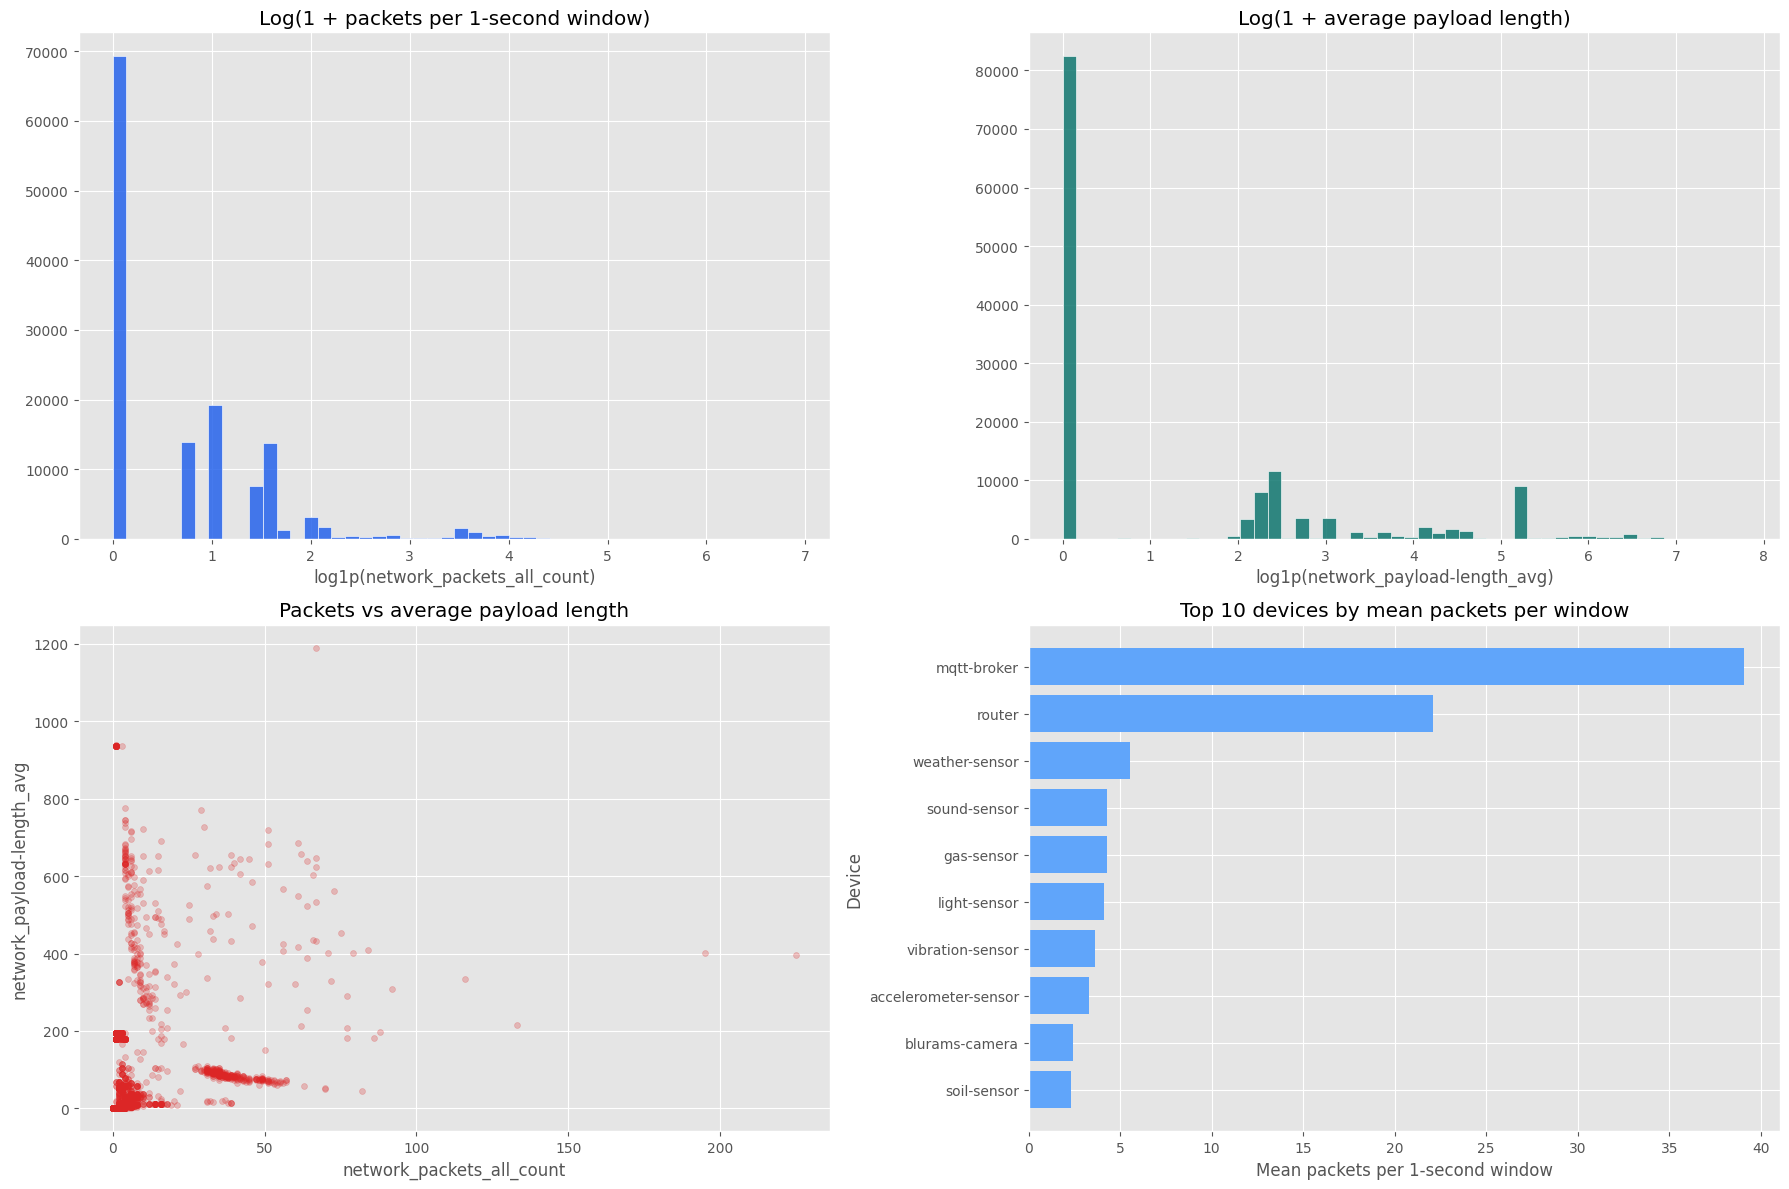

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].hist(np.log1p(df['network_packets_all_count']), bins=50, color='#2563eb', alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Log(1 + packets per 1-second window)')
axes[0, 0].set_xlabel('log1p(network_packets_all_count)')

axes[0, 1].hist(np.log1p(df['network_payload-length_avg']), bins=50, color='#0f766e', alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Log(1 + average payload length)')
axes[0, 1].set_xlabel('log1p(network_payload-length_avg)')

sample_df = df.sample(min(10000, len(df)), random_state=42)
axes[1, 0].scatter(sample_df['network_packets_all_count'], sample_df['network_payload-length_avg'], alpha=0.25, s=18, color='#dc2626')
axes[1, 0].set_title('Packets vs average payload length')
axes[1, 0].set_xlabel('network_packets_all_count')
axes[1, 0].set_ylabel('network_payload-length_avg')

top_devices = device_observation_summary.head(10).reset_index().sort_values('mean_packets')
axes[1, 1].barh(top_devices['device_name'], top_devices['mean_packets'], color='#60a5fa')
axes[1, 1].set_title('Top 10 devices by mean packets per window')
axes[1, 1].set_xlabel('Mean packets per 1-second window')
axes[1, 1].set_ylabel('Device')

plt.tight_layout()
plt.show()


### How to interpret these plots (benign traffic)

<div style="padding: 12px 16px; background: #eff6ff; border-radius: 8px; border: 1px solid #93c5fd;">
These four panels are a quick visual summary of what <b>normal (benign)</b> IIoT traffic looks like in <b>1-second windows</b>: it is often <b>sparse</b> (many windows have little activity), occasionally <b>bursty</b> (short spikes), and <b>heterogeneous by device</b> (some devices talk much more than others).
</div>

A note about the axis transform used in the two histograms:

- We plot <code>log(1 + x)</code> (also written <code>log1p(x)</code>) because packet counts and payload lengths are usually <b>right-skewed</b> and include many zeros.
- The <code>+1</code> ensures that zeros remain defined (<code>log(1+0)=0</code>).
- Log scaling compresses extreme values so we can see both the many small windows and the rare large bursts in one figure.

#### Panel (a): Histogram of <code>log(1 + packets)</code>

- A large mass near the left side (values near 0) means many 1-second windows have <b>0 or very few packets</b>. This is common in IoT because devices often sleep, report periodically, or only transmit on events.
- A long tail to the right means benign traffic still has <b>occasional bursts</b>. These bursts can happen during normal operations (status synchronization, retries, firmware/app interactions, or short-lived connectivity events).
- The key EDA insight is: <b>high packets alone does not automatically imply an attack</b>. We should expect some high-activity benign windows, just not in a sustained, repetitive way across many seconds.

#### Panel (b): Histogram of <code>log(1 + average payload length)</code>

- Values near 0 indicate many windows with <b>little or no payload</b> on average. In benign networks this can still be normal because some traffic is control/handshake-heavy rather than content-heavy.
- A skewed distribution (many small values with a tail) indicates that benign devices sometimes send or receive <b>larger content</b> (e.g., application messages, updates, or bursts of telemetry).
- In later comparisons, one “attack-like” pattern is often <b>many packets with low payload</b> (flood-like behavior). This panel helps us establish what “low payload” looks like under benign conditions.

#### Panel (c): Scatter of <code>packets</code> vs <code>average payload length</code>

- Each dot is one sampled 1-second window.
- A broad upward trend would mean: when a window has more packets, it also tends to carry more payload. That is a reasonable benign pattern when traffic represents real communication rather than pure signaling.
- If you see many points with <b>high packets but near-zero payload</b>, that suggests bursts dominated by control/headers rather than content. In benign data this can still occur (e.g., retries/keep-alives), but in attacks it can become <b>much more frequent and extreme</b>.
- This plot is useful because attacks often change not only the level of a variable, but the <b>relationship</b> between variables (e.g., packet volume rises while payload stays low).

#### Panel (d): Top 10 devices by mean packets per window

- This plot shows that the benign baseline is <b>device-dependent</b>: some devices generate much more traffic than others.
- Devices with consistently higher baseline traffic can dominate global summaries. If we ignore this, a model might learn “device identity” rather than “attack behavior.”
- This motivates later checks such as: per-device evaluation, adding <code>device_name</code> carefully (or excluding it), and building graph representations where the device is a first-class entity.

#### Takeaway you can use in the paper (EDA)

Overall, benign IIoT traffic in 1-second windows is characterized by <b>sparsity</b> (many near-idle windows), <b>heavy-tailed bursts</b> (occasional spikes), and <b>strong device heterogeneity</b>. These properties justify (1) using log transforms for visualization, (2) relying on class-sensitive metrics later (precision/recall/F1), and (3) considering graph-based representations that explicitly model devices and their interaction patterns.


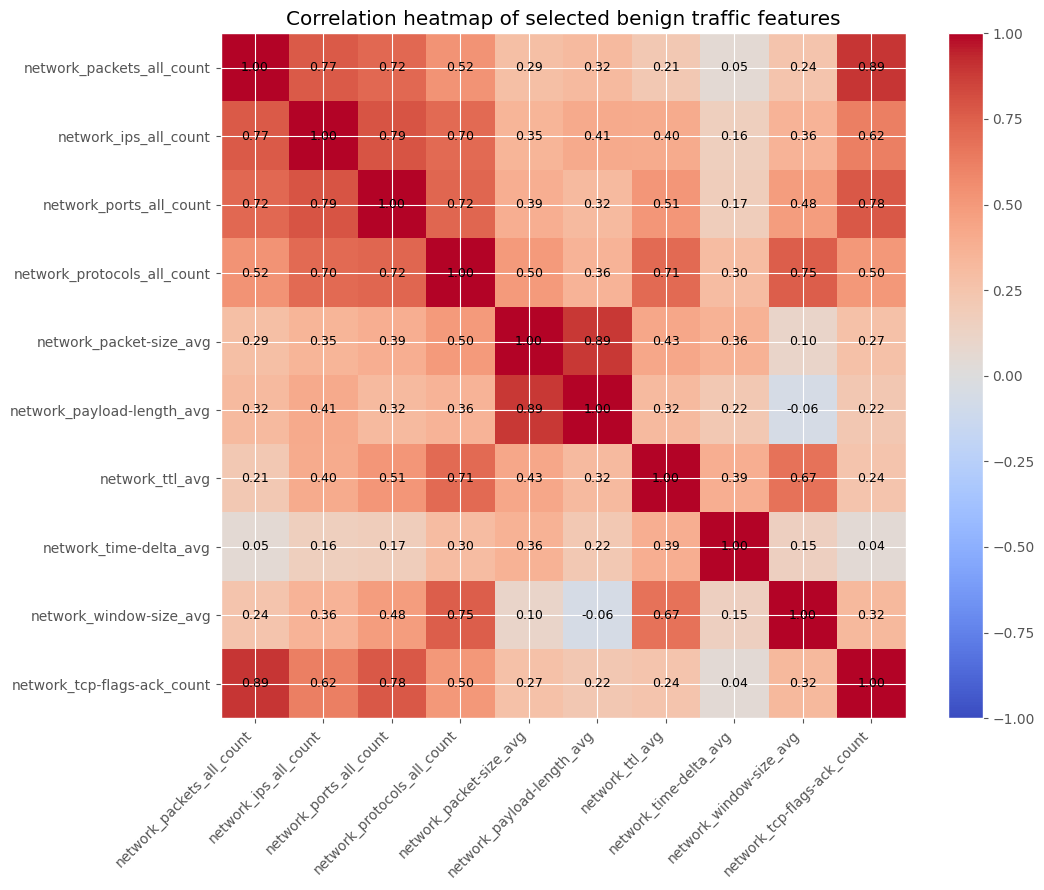

In [10]:
corr_features = [
    'network_packets_all_count',
    'network_ips_all_count',
    'network_ports_all_count',
    'network_protocols_all_count',
    'network_packet-size_avg',
    'network_payload-length_avg',
    'network_ttl_avg',
    'network_time-delta_avg',
    'network_window-size_avg',
    'network_tcp-flags-ack_count'
]

corr = df[corr_features].corr()
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation heatmap of selected benign traffic features')

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Correlation interpretation

A correlation heatmap shows how strongly pairs of variables move together.

### How to read the heatmap

- Each row and column is one feature.
- The value where two features meet is their correlation coefficient.
- Values close to `+1` mean the two variables tend to increase together.
- Values close to `-1` mean one tends to increase when the other decreases.
- Values close to `0` mean there is little or no linear relationship.
- The diagonal is always `1.00` because each variable is perfectly correlated with itself.

### How to interpret the colors

- Warm colors near the positive end mean a strong positive relationship.
- Cool colors near the negative end mean a strong negative relationship.
- Colors near the center mean weak relationship.

### What that means in this benign dataset

When two benign features are strongly positively correlated, it means they often rise and fall together during normal IoT behavior. For example, if packet counts and payload-related features increase together, that suggests a normal traffic pattern in which more communication also carries more data.

If a feature has weak correlation with most others, that can mean it carries different information. That is useful because such variables may add unique value to a model instead of repeating what other columns already capture.

If we saw strong negative correlation, that would suggest a trade-off, where one behavior grows while another shrinks. Even if negative correlations are not dominant here, they would still be important to notice.

### Why this heatmap matters for your project

This graph helps us answer an early research question: are the benign variables behaving in a stable and interpretable way, or are they mostly unrelated noise?

- If several features move together, classical models may exploit those regular numeric patterns.
- If some features behave independently, they may capture complementary information.
- Later, when we compare against attack traffic, we can check whether those benign relationships stay the same or break apart.

That last point is especially important. Sometimes an attack is not only a change in one variable; it is a change in the relationship between variables. For example, packet count may become very high while payload stays very low, which can indicate flood-like behavior. A heatmap helps us build that intuition.

**Flood-like behavior** means traffic that sends a very large number of packets in a short period of time, often with repetitive or low-content packets, in a way that overwhelms or stresses the target system. In practice, this kind of behavior is often associated with DoS or DDoS attacks.

### Practical rule for you

When you look at a heatmap, ask yourself:

1. Which variables move together?
2. Which variables seem to behave differently from the rest?
3. Do those relationships make sense for normal traffic?
4. Would an attack likely preserve those relationships or disrupt them?

That is the main interpretation you want to carry into the rest of the project.


## <div style="color:#1d4ed8;">7. Temporal behavior across the one-hour capture</div>

Because the data is aggregated by second, we can examine how normal traffic changes over time.

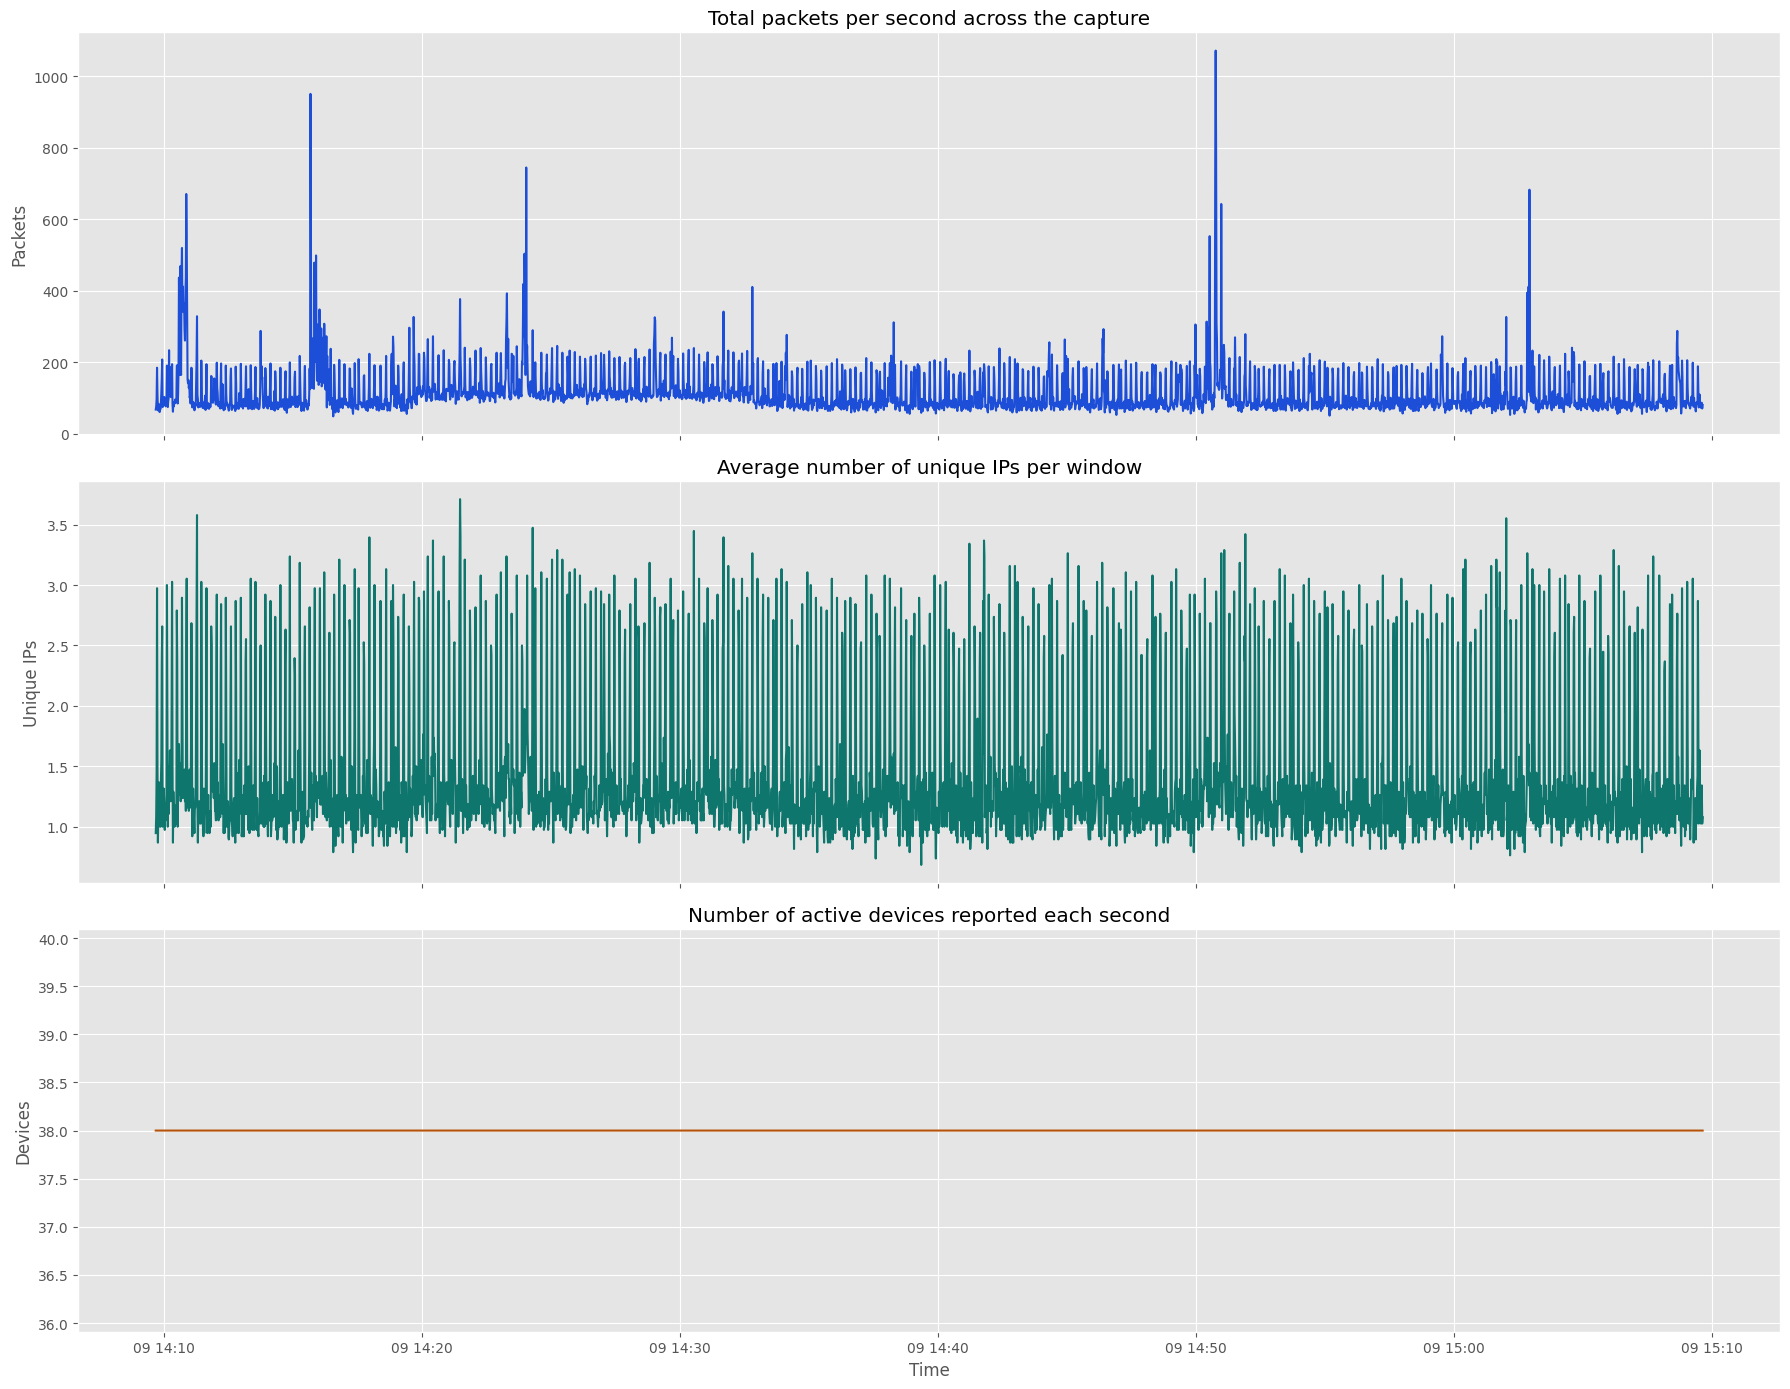

In [11]:
traffic_over_time = (
    df.groupby('timestamp_start')
      .agg(
          total_packets=('network_packets_all_count', 'sum'),
          active_devices=('device_name', lambda s: s.nunique()),
          mean_unique_ips=('network_ips_all_count', 'mean')
      )
      .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

axes[0].plot(traffic_over_time['timestamp_start'], traffic_over_time['total_packets'], color='#1d4ed8')
axes[0].set_title('Total packets per second across the capture')
axes[0].set_ylabel('Packets')

axes[1].plot(traffic_over_time['timestamp_start'], traffic_over_time['mean_unique_ips'], color='#0f766e')
axes[1].set_title('Average number of unique IPs per window')
axes[1].set_ylabel('Unique IPs')

axes[2].plot(traffic_over_time['timestamp_start'], traffic_over_time['active_devices'], color='#b45309')
axes[2].set_title('Number of active devices reported each second')
axes[2].set_ylabel('Devices')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()


### Interpretation

These time-series plots help answer whether benign behavior is stable or bursty.

- If `total_packets` stays low most of the time but spikes occasionally, then benign activity naturally contains bursts.
- If `mean_unique_ips` rises during some periods, the network becomes more diverse in its communication partners.
- If active devices fluctuate, the environment is dynamic, which is important when comparing future attack windows.

This is one reason graph approaches may help: they can preserve the structure of who talks to whom instead of reducing everything to only flat summary numbers.


## <div style="color:#1d4ed8;">8. Why this dataset is useful for graph construction</div>

Although this file has no attacks, it is still valuable for building the graph representation of normal IoT behavior.

In [12]:
graph_candidate_features = pd.DataFrame({
    'Graph role': [
        'Device node',
        'MAC node',
        'IP node',
        'Port node',
        'Protocol node',
        'Time/event node',
        'Edge attributes'
    ],
    'Candidate columns': [
        'device_name, device_mac',
        'network_macs_all, network_macs_src, network_macs_dst',
        'network_ips_all, network_ips_src, network_ips_dst',
        'network_ports_all, network_ports_src, network_ports_dst',
        'network_protocols_all, network_protocols_src, network_protocols_dst',
        'timestamp_start, timestamp_end',
        'packet counts, payload length, TTL, window size, TCP flags'
    ],
    'Why useful': [
        'Represents the IoT endpoint being observed',
        'Captures hardware-level communication relationships',
        'Captures who communicates with whom',
        'Captures service access behavior',
        'Captures communication semantics',
        'Supports temporal graphs or event graphs',
        'Adds traffic intensity and context to graph edges'
    ]
})

graph_candidate_features


,Graph role,Candidate columns,Why useful
0,Device node,"device_name, device_mac",Represents the IoT endpoint being observed
1,MAC node,"network_macs_all, network_macs_src, network_ma...",Captures hardware-level communication relation...
2,IP node,"network_ips_all, network_ips_src, network_ips_dst",Captures who communicates with whom
3,Port node,"network_ports_all, network_ports_src, network_...",Captures service access behavior
4,Protocol node,"network_protocols_all, network_protocols_src, ...",Captures communication semantics
5,Time/event node,"timestamp_start, timestamp_end",Supports temporal graphs or event graphs
6,Edge attributes,"packet counts, payload length, TTL, window siz...",Adds traffic intensity and context to graph edges


### Graph insight

This table is the bridge between your current knowledge of tabular modeling and future graph work.

In a classical model, each row becomes a feature vector.
In a graph model, the same row can become:

- a set of nodes,
- a set of edges,
- and attributes attached to those nodes or edges.

That is why this dataset is still important even though it is only benign.


## <div style="color:#1d4ed8;">9. Final evaluation: does this dataset serve the project?</div>

<div style="padding: 14px 18px; background: #f8fafc; border-radius: 8px; border-left: 6px solid #0f766e;">
<b>Short answer:</b> Yes, but only as a <b>benign baseline dataset</b>, not as a complete attack-detection dataset by itself.
</div>

### Strengths

- Large number of observations.
- Many IoT devices are represented.
- Fine temporal granularity (1-second windows).
- Rich network context: IPs, MACs, ports, protocols, packet metrics, TTL, and TCP flags.
- Very useful for defining graph entities and normal communication patterns.

### Limitations

- All rows are labeled benign.
- It cannot train a supervised benign-vs-attack classifier alone.
- It cannot by itself test the hypothesis that GNNs outperform non-graph models for attack detection.

### Best use of this file

- Build a normal-behavior baseline.
- Support anomaly detection experiments.
- Build the initial knowledge graph schema.
- Compare future attack windows against this benign reference.


## <div style="color:#1d4ed8;">10. What should happen next?</div>

To advance the project, the next notebook should use either:

1. an attack dataset from the same environment, or
2. a combined benign + attack dataset.

Then we will be able to:

- compare class distributions,
- identify which features change most under attack,
- train normal models,
- and later compare them against a graph-based approach.

## Suggested next step for the project

Once you send the attack dataset, we should build a second notebook that answers these questions:

- Which variables differ most between benign and malicious traffic?
- Which devices are most affected?
- Which protocols, ports, or IP relationship patterns become suspicious?
- Does graph structure add information beyond normal tabular features?
